# **1**

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!mkdir "/content/drive/MyDrive/ICT DSA Online/Rain_Audio"

In [ ]:
!mv "/content/drive/MyDrive/ICT DSA Online/rainfall_sound_8k.zip" "/content/drive/MyDrive/ICT DSA Online/Rain_Audio/"

In [ ]:
!mv "/content/drive/MyDrive/ICT DSA Online/"*.wav "/content/drive/MyDrive/ICT DSA Online/Rain_Audio/"

In [ ]:
!unzip -u "/content/drive/MyDrive/ICT DSA Online/Rain_Audio/rainfall_sound_8k.zip" -d "/content/drive/MyDrive/ICT DSA Online/Rain_Audio"

Archive:  /content/drive/MyDrive/ICT DSA Online/Rain_Audio/rainfall_sound_8k.zip


In [ ]:
!unzip -o "/content/drive/MyDrive/ICT DSA Online/Rain_Audio/rainfall_sound_8k.zip" -d "/content/drive/MyDrive/ICT DSA Online/Rain_Audio"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_43_09_705665.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_43_19_880023.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_43_30_052520.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_43_40_226009.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_43_50_399196.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_44_00_572090.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_44_10_745918.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_04_44_20_918796.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_05_00_16_670031.wav  
  inflating: /content/drive/MyDrive/ICT DSA Online/Rain_Audio/2024_05_25_05_00_26_842711.wav  

In [2]:
import os

folder = "/content/drive/MyDrive/ICT DSA Online/Rain_Audio"
wav_files = [f for f in os.listdir(folder) if f.endswith(".wav")]
print("Total WAV files extracted:", len(wav_files))

Total WAV files extracted: 36777


## a.

In [ ]:
import librosa
import os

folder_path = "/content/drive/MyDrive/ICT DSA Online/Rain_Audio"  # main folder

# pick first WAV file
file_path = os.path.join(folder_path,wav_files[0])

audio, sr = librosa.load(file_path,sr=None) # sr=None avoids the default 22050 resolution and gives for the data

print("File name:",wav_files[0])
print("Sampling Rate:", sr)

File name: 2024_05_17_10_28_27_892256.wav
Sampling Rate: 8000


In [ ]:
audio

array([0.00128174, 0.00292969, 0.00274658, ..., 0.02368164, 0.01879883,
       0.02700806], dtype=float32)

## b.

In [ ]:
print("Length (in samples):", len(audio))
print("Duration (seconds):", len(audio) / sr)

Length (in samples): 80000
Duration (seconds): 10.0


## c.

In [3]:
import pandas as pd

# Load CSV (update path if needed)
csv_path = "/content/rain_data_mechanical_master.csv"
df = pd.read_csv(csv_path)
df.head()

,Time,device_frmpayload_data_rainfall
0,2023-11-22 18:27:26,800 µm
1,2023-11-22 18:30:26,1.40 mm
2,2023-11-22 18:33:26,1 mm
3,2023-11-22 18:36:26,1.40 mm
4,2023-11-22 18:39:26,200 µm


In [ ]:
df

,Time,device_frmpayload_data_rainfall
0,2023-11-22 18:27:26,800.0
1,2023-11-22 18:30:26,1.4
2,2023-11-22 18:33:26,1.0
3,2023-11-22 18:36:26,1.4
4,2023-11-22 18:39:26,200.0
...,...,...
1343,2024-05-29 16:47:56,0.6
1344,2024-05-29 17:02:56,0.6
1345,2024-05-29 17:05:56,0.6
1346,2024-05-29 17:08:56,0.6


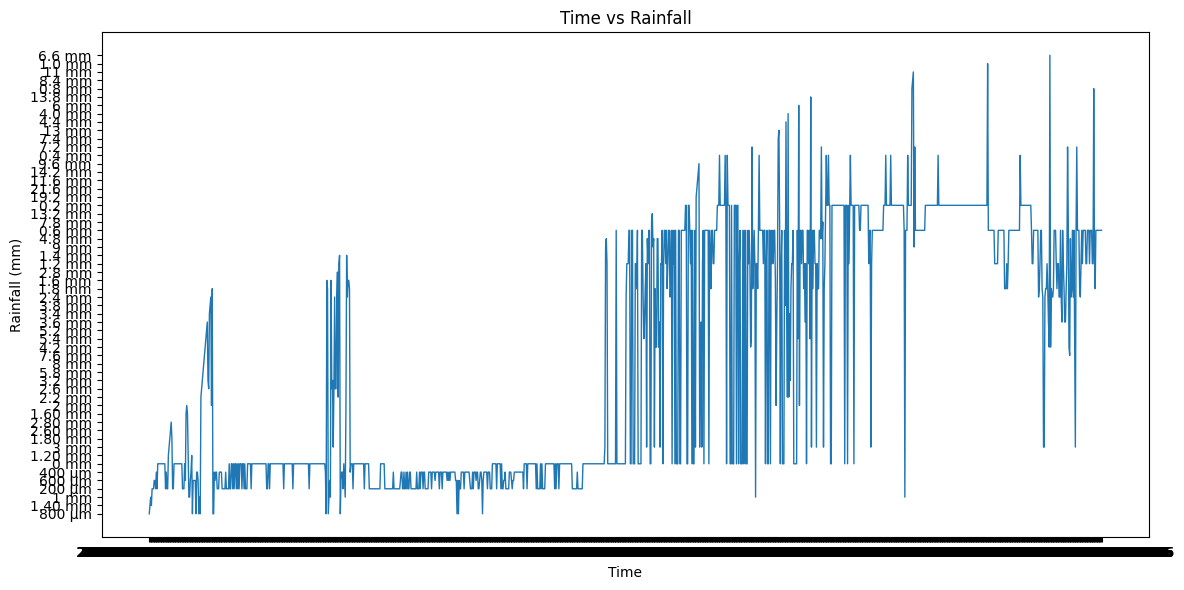

In [ ]:
import matplotlib.pyplot as plt

# Sorting by timestamp (important for line plot)
df = df.sort_values(by='Time')

# Plot time vs rainfall
plt.figure(figsize=(12, 6))
plt.plot(df['Time'], df['device_frmpayload_data_rainfall'], linewidth=1)

plt.title("Time vs Rainfall")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

## d.

In [ ]:
df.isnull().sum()

,0
Time,0
device_frmpayload_data_rainfall,0


In [14]:
df['device_frmpayload_data_rainfall'] = (
    df['device_frmpayload_data_rainfall']
    .astype(str)            # convert everything to string
    .str.strip()            # remove spaces
    .str.extract('([0-9.]+)')  # extract only digits and decimal point that starts with digit and + for combination of digits or digits with decimal points
)

# Convert rainfall column to numeric (float)
df['device_frmpayload_data_rainfall'] = pd.to_numeric(df['device_frmpayload_data_rainfall'], errors='coerce')

# Filter out zero rainfall
df_nonzero = df[df['device_frmpayload_data_rainfall'] > 0]

# Maximum rainfall
max_row = df_nonzero.loc[df_nonzero['device_frmpayload_data_rainfall'].idxmax()] # a dataframe

# Minimum non-zero rainfall
min_row = df_nonzero.loc[df_nonzero['device_frmpayload_data_rainfall'].idxmin()]

print("Maximum Rainfall Observed:")
print("Date & Time:", max_row['Time'])
print("Rainfall (mm):", max_row['device_frmpayload_data_rainfall'])

print("\nMinimum Non-Zero Rainfall Observed:")
print("Date & Time:", min_row['Time'])
print("Rainfall (mm):", min_row['device_frmpayload_data_rainfall'])

Maximum Rainfall Observed:
Date & Time: 2023-11-22 18:27:26
Rainfall (mm): 800.0

Minimum Non-Zero Rainfall Observed:
Date & Time: 2024-05-15 18:47:28
Rainfall (mm): 0.2


# **2.**

Handling missing values

In [ ]:
df.isnull().sum()

,0
Time,0
device_frmpayload_data_rainfall,0


Handling duplicates

In [ ]:
df.shape

(1348, 2)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(1347, 2)

Detecting and Handling Outliers

<Axes: ylabel='device_frmpayload_data_rainfall'>

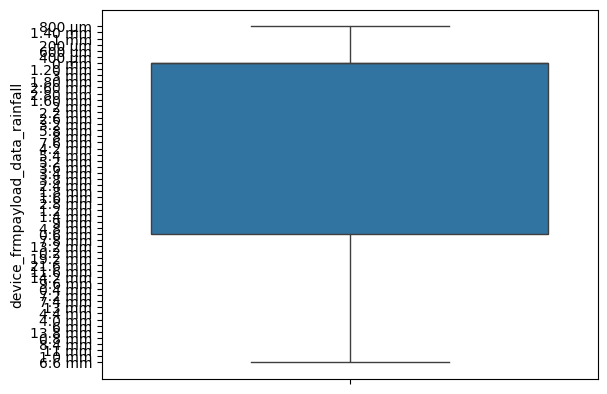

In [10]:
import seaborn as sns
sns.boxplot(df['device_frmpayload_data_rainfall'])

Understanding Feature types

<Axes: xlabel='device_frmpayload_data_rainfall', ylabel='count'>

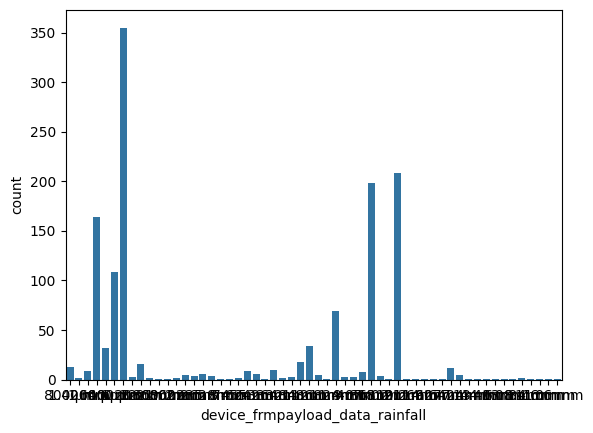

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='device_frmpayload_data_rainfall',data=df)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['device_frmpayload_data_rainfall'] = scaler.fit_transform(
    df[['device_frmpayload_data_rainfall']]
)

df.head()

,Time,device_frmpayload_data_rainfall
0,2023-11-22 18:27:26,4.457551
1,2023-11-22 18:30:26,-0.480043
2,2023-11-22 18:33:26,-0.482516
3,2023-11-22 18:36:26,-0.480043
4,2023-11-22 18:39:26,0.747864


## i)

In [ ]:
import os
import pandas as pd
from datetime import datetime, timedelta

# Convert 'Time' column to datetime
df['Time'] = pd.to_datetime(df['Time'])

# Collecting WAV files
audio_files = sorted(wav_files)

# Convert filename → timestamp function
def filename_to_timestamp(fname):
    return datetime.strptime(fname[:-4], "%Y_%m_%d_%H_%M_%S_%f")

# Create dict mapping
audio_timestamp_map = {}
for f in audio_files:
    t = filename_to_timestamp(f)
    audio_timestamp_map[t] = f

# Store results: CSV timestamp → relevant audio clips list
relevant_audio_clips = {}

for ts in df['Time']:
    start_time = ts - timedelta(minutes=3)
    clips = [fname for t, fname in audio_timestamp_map.items() if start_time <= t <= ts]
    clips.sort()  # chronological order
    relevant_audio_clips[ts] = clips

# Show sample result
sample_ts = df['Time'].iloc[0]
print("Timestamp:", sample_ts)
print("Relevant audio clips:", relevant_audio_clips[sample_ts])
print("Number of clips:", len(relevant_audio_clips[sample_ts]))

Timestamp: 2023-11-22 18:27:26
Relevant audio clips: ['2023_11_22_18_24_26_836772.wav', '2023_11_22_18_24_36_917269.wav', '2023_11_22_18_24_46_992185.wav', '2023_11_22_18_24_57_147591.wav', '2023_11_22_18_25_07_224895.wav', '2023_11_22_18_25_17_379285.wav', '2023_11_22_18_25_27_455776.wav', '2023_11_22_18_25_37_611929.wav', '2023_11_22_18_25_47_613746.wav', '2023_11_22_18_25_57_770008.wav', '2023_11_22_18_26_07_846418.wav', '2023_11_22_18_26_18_004594.wav', '2023_11_22_18_26_28_158875.wav', '2023_11_22_18_26_38_239084.wav', '2023_11_22_18_26_48_393340.wav', '2023_11_22_18_26_58_472759.wav', '2023_11_22_18_27_08_551740.wav', '2023_11_22_18_27_18_626446.wav']
Number of clips: 18


## ii)

In [ ]:
import librosa
import numpy as np
import os

combined_data = []  # store combined audio for each timestamp

valid_items = [(ts, clips) for ts, clips in relevant_audio_clips.items() if len(clips) > 0]

print("Processing audio for", len(valid_items), "timestamps...")

for ts, clips in valid_items:
    audio_arrays = []

    for fname in clips:
        file_path = os.path.join("/content/drive/MyDrive/ICT DSA Online/Rain_Audio", fname)
        audio, sr = librosa.load(file_path, sr=None)
        audio_arrays.append(audio)

    combined_audio = np.concatenate(audio_arrays)
    combined_data.append(combined_audio)

print("Total combined audio segments:", len(combined_data))

In [ ]:
# Get all timestamps
all_ts = list(relevant_audio_clips.keys())

# Already processed timestamps count
processed_count = len(combined_data)

# Remaining timestamps to process
remaining_ts = all_ts[processed_count:]
print("Remaining timestamps:", len(remaining_ts))

Remaining timestamps: 502


In [ ]:
import librosa
import os
import numpy as np

for ts in remaining_ts:
    audio_arrays = []

    for fname in relevant_audio_clips[ts]:
        file_path = os.path.join("/content/drive/MyDrive/ICT DSA Online/Rain_Audio", fname)
        audio, sr = librosa.load(file_path, sr=None)
        audio_arrays.append(audio)

    if audio_arrays:
        combined_audio = np.concatenate(audio_arrays)
        combined_data.append(combined_audio)

print("Now total combined audios:", len(combined_data))

Now total combined audios: 1346


## iii)

In [ ]:
np.savez_compressed(
    "/content/drive/MyDrive/ICT DSA Online/combined_dataset.npz",
    *combined_data
)

print("Saved as compressed NPZ!")

Saved as compressed NPZ!


In [ ]:
import numpy as np

# Load combined audio data
data = np.load("/content/drive/MyDrive/ICT DSA Online/combined_dataset.npz")
combined_data = [data[key] for key in data]

print("Total combined audio segments:", len(combined_data))

Total combined audio segments: 1346


## iv)

In [ ]:
import librosa

features_list = []

for audio in combined_data:
    # Convert audio to float32 for librosa
    audio = audio.astype(np.float32)

    mean_amp = np.mean(audio)
    std_amp = np.std(audio)
    max_amp = np.max(audio)
    min_amp = np.min(audio)
    rms = np.sqrt(np.mean(audio**2))
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=8000))  # assuming 8kHz

    features_list.append([mean_amp, std_amp, max_amp, min_amp, rms, zcr, spec_centroid])

features_array = np.array(features_list)
print("Feature array shape:", features_array.shape)

Feature array shape: (1346, 7)


In [ ]:
features_array

array([[-1.49532952e-05,  1.65602826e-02,  9.99969482e-01, ...,
         1.65602937e-02,  1.47565259e-01,  1.53554944e+03],
       [-1.63848035e-05,  1.89399216e-02,  8.54370117e-01, ...,
         1.89399328e-02,  1.92240824e-01,  1.61995227e+03],
       [-1.18586222e-05,  1.30579956e-02,  5.39978027e-01, ...,
         1.30580021e-02,  1.61679764e-01,  1.53318864e+03],
       ...,
       [-3.04493074e-06,  6.59343833e-03,  5.06792307e-01, ...,
         6.59343880e-03,  7.11902953e-02,  1.06303210e+03],
       [ 1.35719745e-06,  5.67689305e-03,  1.49825320e-01, ...,
         5.67689491e-03,  5.26417541e-02,  8.63895373e+02],
       [-9.04651097e-06,  1.56960562e-02,  8.93504202e-01, ...,
         1.56960580e-02,  4.23128690e-02,  4.49757686e+02]])

## v)

In [ ]:
# Use rainfall values corresponding to combined_data segments
# If lengths mismatch, trim to smallest length
num_segments = features_array.shape[0]
targets = df['device_frmpayload_data_rainfall'].values[:num_segments]


# Create DataFrame

features_df = pd.DataFrame(features_array, columns=[
    "Mean", "StdDev", "Max", "Min", "RMS", "ZCR", "SpectralCentroid"
])
features_df['Rainfall'] = targets

print("Preprocessed dataset shape:", features_df.shape)
print(features_df.head())


# Save preprocessed dataset

# CSV
csv_out = "/content/drive/MyDrive/ICT DSA Online/preprocessed_data.csv"
features_df.to_csv(csv_out, index=False)
print("Saved preprocessed data as CSV:", csv_out)

Preprocessed dataset shape: (1346, 8)
       Mean    StdDev       Max       Min       RMS       ZCR  \
0 -0.000015  0.016560  0.999969 -1.000000  0.016560  0.147565   
1 -0.000016  0.018940  0.854370 -0.996643  0.018940  0.192241   
2 -0.000012  0.013058  0.539978 -0.469696  0.013058  0.161680   
3 -0.000014  0.017015  0.905823 -0.848969  0.017015  0.157726   
4 -0.000016  0.005300  0.156769 -0.155762  0.005300  0.072928   

   SpectralCentroid Rainfall  
0       1535.549443   800 µm  
1       1619.952270  1.40 mm  
2       1533.188640     1 mm  
3       1506.793005  1.40 mm  
4       1244.716797   200 µm  
Saved preprocessed data as CSV: /content/drive/MyDrive/ICT DSA Online/preprocessed_data.csv
